In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
import wavelet_funcs as wf

path.append('../signals/')
import signals as sg

path.append('../fourier/')
import stft


In [2]:
from ssqueezepy import ssq_cwt

## Cosine with a phase shift

In [3]:
fs = 100
t,s = sg.cosine(10, 2, fs)

## Phase shift at t=4 s
t_shift = 4
ndrop = 30
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]

In [59]:
ft_window = 200 # samples
p = stft.windowed_periodogram(s, fs, ft_window, overlap=ft_window-1, window=('gaussian', 35))

[(1.0, 5.0), (0.0, 9.68), Text(0, 0.5, 'Frequency (Hz)')]

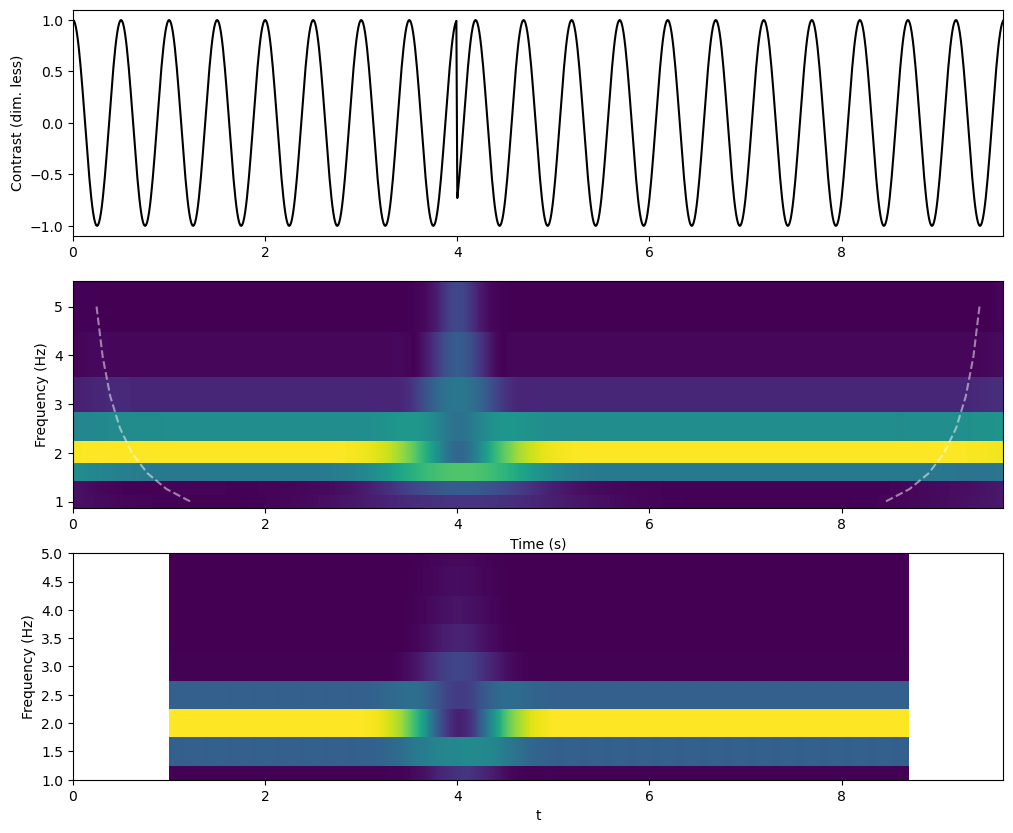

In [60]:
f, (ax,ax1,ax2) = plt.subplots(3,1, figsize=(12,10))

wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, show_smoothed=0, nscales=8, axs=(ax,ax1))

p.plot.imshow(ax=ax2, add_colorbar=False)
ax2.set(ylim=(1, 5), xlim=ax.get_xlim(), ylabel=ax1.get_ylabel())

# Cosine with changing frequency

In [77]:
fs = 100
t,freq_func, s = sg.cosine_with_arctan_freq(10, fs, 2, 0.6, 1)

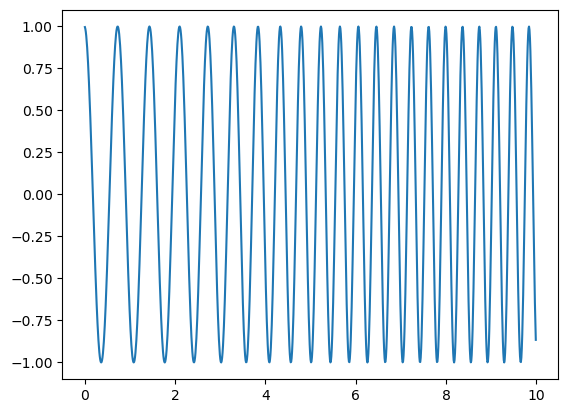

In [78]:
plt.plot(t,s )

In [119]:
ft_window = 200 # samples
p = stft.windowed_periodogram(s, fs, ft_window, overlap=ft_window-1, window=('gaussian', 35))

wt = wf.cwt_with_coi(s, t, freq_min=0.5, freq_max=5, nscales=64, padding_fraction=0.2)

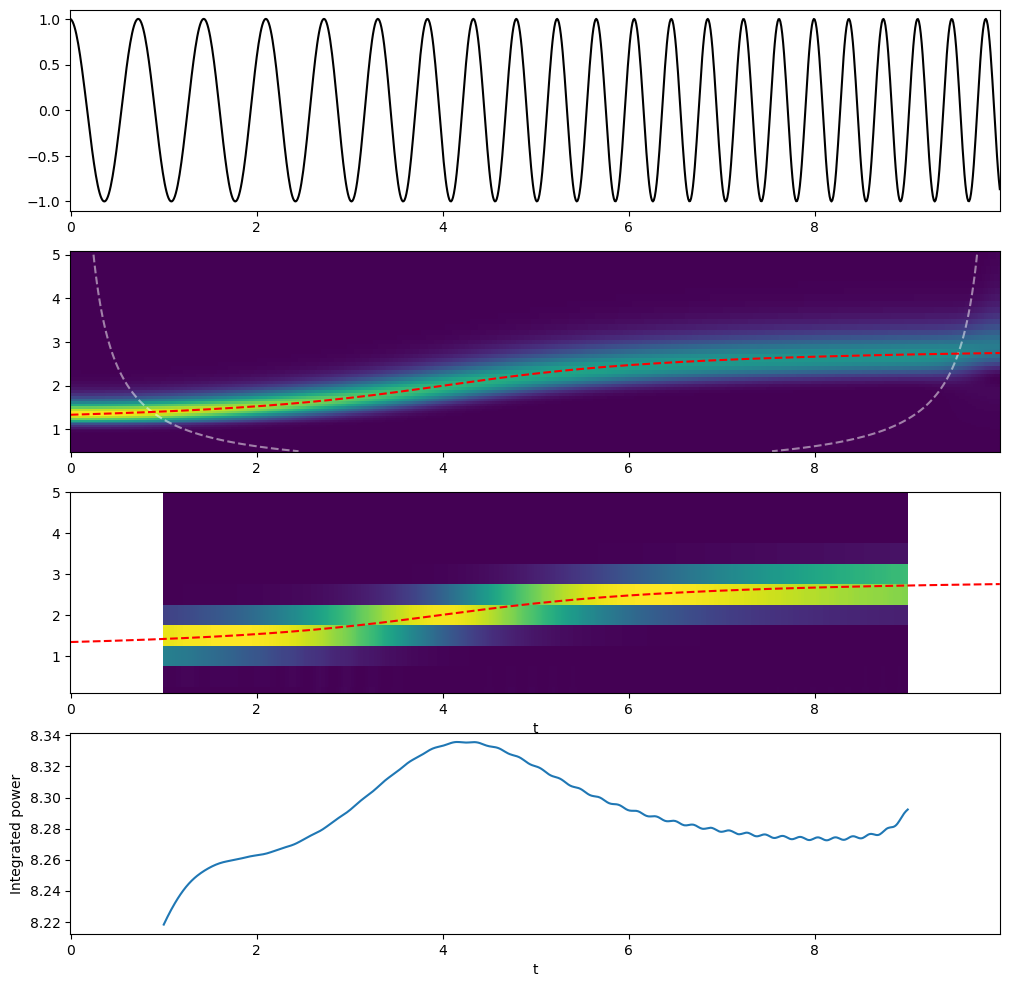

In [169]:
f, (ax,ax1,ax2,ax3) = plt.subplots(4,1, figsize=(12,12))

ax.plot(t,s, color='k')
wf.plot_cwt(wt.wt_amp**(2), wt.f, wt.t, coi=wt.coi, ax=ax1)
ax1.plot(t, freq_func, color='r', ls='--')

p.plot.imshow(ax=ax2, add_colorbar=False)
ax2.set(ylim=(0.1, 5), ylabel=ax1.get_ylabel())
ax2.plot(t, freq_func, color='r', ls='--')

((wt.wt_amp**2).integrate('f')*(-1)).sel(t=slice(1, 9)).plot(ax=ax3)
# (p.sel(f=slice(0.1,5)).integrate('f')*15).plot(ax=ax3)

ax3.set(ylabel='Integrated power')

xlim = ax1.get_xlim()
for axi in (ax,ax1,ax2,ax3):
    axi.set_xlim(xlim)

In [161]:
import ssqueezepy as sq
from ssqueezepy import Wavelet

wavelet = Wavelet(('morlet', {'mu': 6}))

In [163]:
Tx, Wx, freqs, scales = sq.ssq_cwt(s, wavelet=wavelet, fs=fs)

(-0.005, 9.995000000000001)

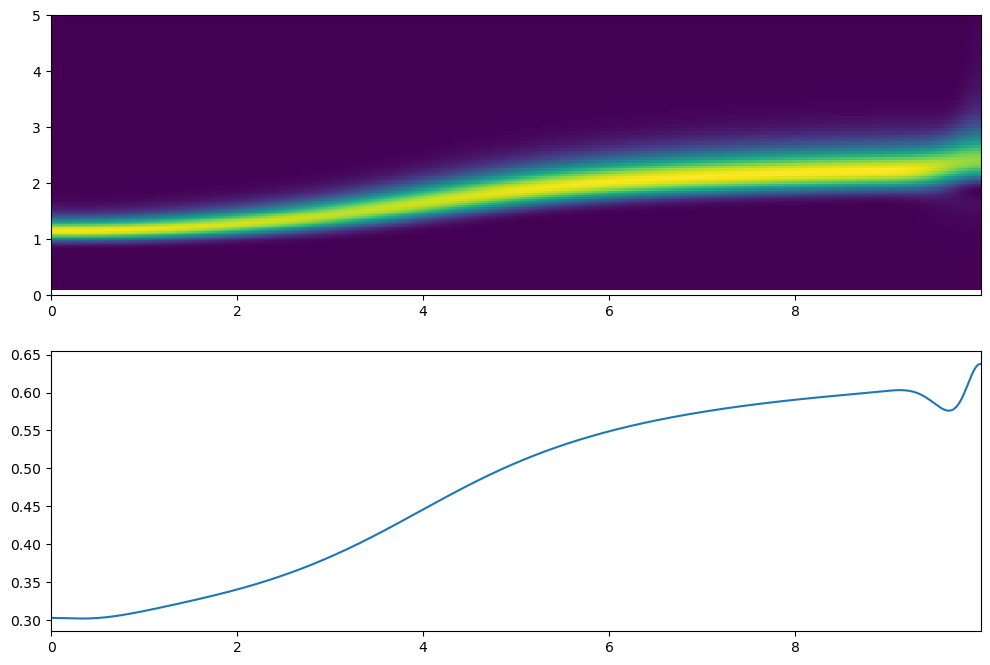

In [167]:

f, (ax,ax1) = plt.subplots(2,1, figsize=(12,8))
wf.plot_cwt(abs(Wx)**2, freqs, t, ax=ax)
ax.set_ylim(0,5)


mask = (freqs > 0.5) & (freqs <= 5)
ax1.plot(t, np.trapz(abs(Wx[mask, :])**2, freqs[mask], axis=0)*(-1))

ax1.set_xlim(ax.get_xlim())